Niveau intermédiaire

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Charger les données
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [ ]:
# 1. Trouvez la corrélation entre « âge », « avg_glucose_level » et « bmi ».
df[['age', 'avg_glucose_level', 'bmi']].corr()

,age,avg_glucose_level,bmi
age,1.000000,0.238171,0.333398
avg_glucose_level,0.238171,1.000000,0.175502
bmi,0.333398,0.175502,1.000000


In [ ]:
# 2. Regroupez les données par « ever_married » (jamais marié) et calculez l'âge moyen pour chaque groupe.
df.groupby('ever_married')['age'].mean()

ever_married
No     22.014229
Yes    54.342082
Name: age, dtype: float64

In [ ]:
# 3. Comptez le nombre de coups pour chaque type de travail.
df.groupby('work_type')['stroke'].sum()

work_type
Govt_job          33
Never_worked       0
Private          149
Self-employed     65
children           2
Name: stroke, dtype: int64

In [ ]:
# 4.  Calculez l'IMC moyen des personnes souffrant d'hypertension et celles qui n'en souffrent pas.
df.groupby('hypertension')['bmi'].mean()

hypertension
0    28.474069
1    33.036585
Name: bmi, dtype: float64

In [ ]:
# 5. Créez une nouvelle colonne « age_group » classant les âges par tranches. (Classez les âges)
bins = [0, 18, 35, 60, 100]
labels = ['Child', 'Youth', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

print(df[['age', 'age_group']])

       age age_group
0     67.0    Senior
1     61.0    Senior
2     80.0    Senior
3     49.0     Adult
4     79.0    Senior
...    ...       ...
5105  80.0    Senior
5106  81.0    Senior
5107  35.0     Youth
5108  51.0     Adult
5109  44.0     Adult

[5110 rows x 2 columns]


In [ ]:
# 6. Trouvez la répartition du statut tabagique des personnes atteintes d'une maladie cardiaque.
df[df['heart_disease'] == 1]['smoking_status'].value_counts()


smoking_status
never smoked       90
formerly smoked    77
smokes             61
Unknown            48
Name: count, dtype: int64

In [ ]:
# 7.  Calculez les taux moyens de glucose chez les personnes vivant en milieu urbain par rapport à celles vivant en milieu rural.
df.groupby('Residence_type')['avg_glucose_level'].mean()

Residence_type
Rural    106.375235
Urban    105.927307
Name: avg_glucose_level, dtype: float64

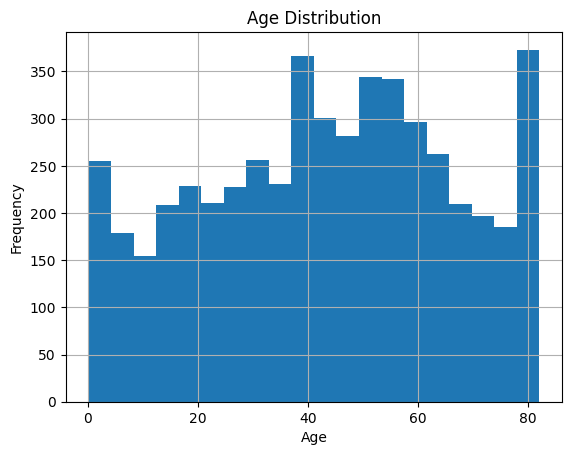

In [ ]:
# 8. Tracer la distribution par âge (nécessite matplotlib ou seaborn).

df['age'].hist(bins=20)
plt.title('Distribution de l\'age')
plt.xlabel('Age')
plt.ylabel('Fréquence')
plt.show()


In [ ]:
# 9. Identifiez les 5 personnes ayant l'IMC le plus élevé.
df.nlargest(5, 'bmi')


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
2128,56420,Male,17.0,1,0,No,Private,Rural,61.67,97.6,Unknown,0,Child
4209,51856,Male,38.0,1,0,Yes,Private,Rural,56.90,92.0,never smoked,0,Adult
928,41097,Female,23.0,1,0,No,Private,Urban,70.03,78.0,smokes,0,Youth
544,545,Male,42.0,0,0,Yes,Private,Rural,210.48,71.9,never smoked,0,Adult
1559,37759,Female,53.0,0,0,Yes,Private,Rural,72.63,66.8,Unknown,0,Adult


In [ ]:
# 10. Vérifiez le pourcentage de valeurs manquantes dans l'ensemble de données.
# Calculez le pourcentage de valeurs manquantes pour chaque colonne.
missing_percentage = df.isnull().mean() * 100

# Afficher le résultat
print("Pourcentage de valeurs manquantes dans chaque colonne :")
print(missing_percentage)

Percentage of missing values in each column:
id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
age_group            0.000000
dtype: float64
